In [1]:
import sys

sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from src.pricer import price_european_option , black_scholes_price

In [7]:
S0, K, r, sigma, T = 100, 100, 0.05, 0.2, 1
n_steps = 252

n_repeats = 20
path_counts = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000]

bs_price = black_scholes_price(S0, K, r, sigma, T, 'call')

mc_prices = []      # mean MC price at each N (averaged over repeats)
std_errors = []     # mean std error at each N
mean_errors = []    # mean |MC price - BS price| at each N

for n in path_counts:
    prices_this_n = []
    se_this_n = []
    err_this_n = []
    for rep in range(n_repeats):
        result = price_european_option(S0, K, r, sigma, T, n_steps, n, 'call', seed=rep)
        prices_this_n.append(result['price'])
        se_this_n.append(result['std_error'])
        err_this_n.append(abs(result['price'] - bs_price))
    mc_prices.append(np.mean(prices_this_n))
    std_errors.append(np.mean(se_this_n))
    mean_errors.append(np.mean(err_this_n))

errors = mean_errors

print("BS price:", bs_price)
print("MC prices:", mc_prices)
print("Mean errors:", errors)

BS price: 10.450583572185565
MC prices: [np.float64(10.910255890745301), np.float64(10.38857805141799), np.float64(10.307707121735648), np.float64(10.369854313033887), np.float64(10.364782294454983), np.float64(10.421943384436526), np.float64(10.428404863756322), np.float64(10.449854864067463)]
Mean errors: [np.float64(1.1102433704369836), np.float64(0.5972842548628867), np.float64(0.4505492084233257), np.float64(0.16825755702206102), np.float64(0.11861407808007822), np.float64(0.05790940013539618), np.float64(0.04816754305460291), np.float64(0.020424458910254017)]


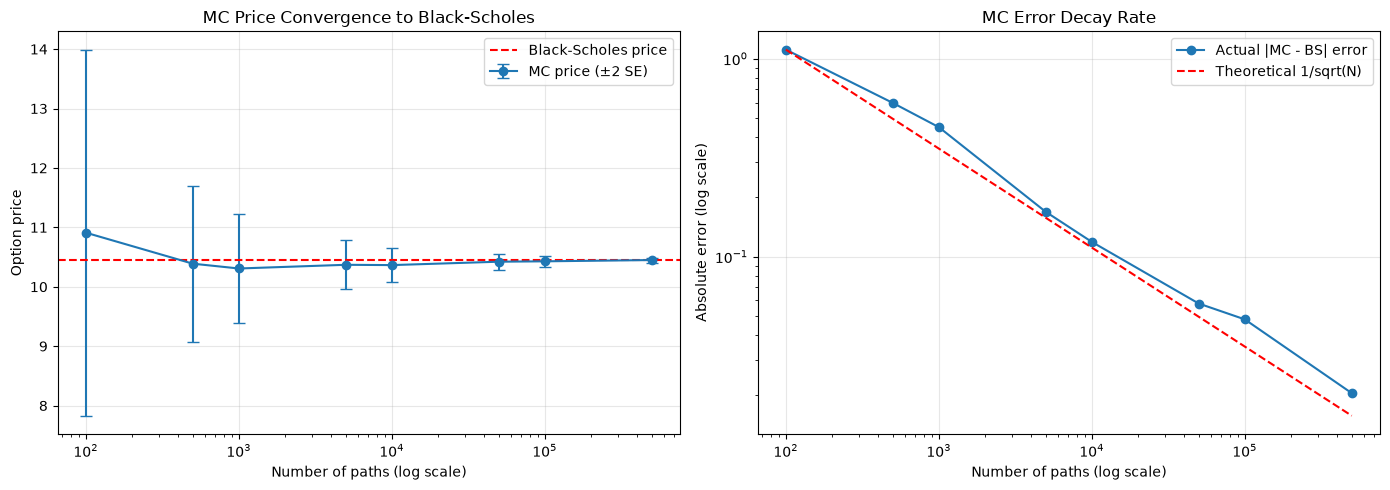

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MC price vs BS price as N increases
axes[0].errorbar(path_counts, mc_prices, yerr=[2*se for se in std_errors], 
                  fmt='o-', capsize=4, label='MC price (±2 SE)')
axes[0].axhline(bs_price, color='red', linestyle='--', label='Black-Scholes price')
axes[0].set_xscale('log')
axes[0].set_xlabel('Number of paths (log scale)')
axes[0].set_ylabel('Option price')
axes[0].set_title('MC Price Convergence to Black-Scholes')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Error decay on log-log scale, compared to theoretical 1/sqrt(N)
axes[1].loglog(path_counts, errors, 'o-', label='Actual |MC - BS| error')

# Theoretical 1/sqrt(N) reference line, anchored to match the first point
ref_line = errors[0] * np.sqrt(path_counts[0] / np.array(path_counts))
axes[1].loglog(path_counts, ref_line, 'r--', label='Theoretical 1/sqrt(N)')

axes[1].set_xlabel('Number of paths (log scale)')
axes[1].set_ylabel('Absolute error (log scale)')
axes[1].set_title('MC Error Decay Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../convergence_analysis.png', dpi=150)
plt.show()